# EDA Analysis for DAC Research Classification Data

This notebook performs exploratory data analysis on the classification data for Direct Air Capture (DAC) research papers.

## Data Overview
The dataset contains classification information for DAC research papers with the following columns:
- **Title**: Paper title
- **Class**: Primary classification category
- **Sub-Class 1, 2, 3**: Hierarchical sub-classifications
- **Secondary_Classification**: Additional classification categories
- **Abstract**: Paper abstract text
- **Keywords**: Comma-separated keywords
- **DOI**: Digital Object Identifier
- **PDF_file_name**: Name of the PDF file
- **Classification_Confidence**: Confidence score (0-100)
- **Classification_Reasoning**: Explanation for classification
- **paper_id**: Unique paper identifier

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 200)

## 1. Data Loading and Initial Exploration

In [2]:
# Load the data
file_path = "data/DAC_2000_2025_merged_extract/classification.csv"
df = pd.read_csv(file_path)

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
display(df.head())

print("\nColumn Information:")
print(df.info())
print("\nMissing Values:")
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing_data, 'Missing_Percentage': missing_percentage})
display(missing_df[missing_df['Missing_Count'] > 0])

Dataset Shape: (2756, 13)

First few rows:


,Title,Class,Sub-Class 1,Sub-Class 2,Sub-Class 3,Secondary_Classification,Abstract,Keywords,DOI,PDF_file_name,Classification_Confidence,Classification_Reasoning,paper_id
0,Enhanced Solar CO2 Photoreduction to Formic Acid by Platinum Immobilization on Bipyridine Covalent Triazine Framework with Defects,Core Capture Materials,Solid Adsorbents,"Crystalline Porous Materials (MOFs, COFs, POPs)",NaN,Electrochemical/Photoelectrochemical DAC - Photoelectrochemical DAC,"The immobilization and structural analysis of platinum nanoparticles on a nitrogen-rich, bipyridine-containing covalent triazine framework (bpyCTF) having structural defects are disclosed by takin...","covalent triazine frameworks, CO2 photoreduction, formic acid, platinum nanoparticles, solar fuels, nitrogen-rich materials",10.1002/adsu.202300071,0008.pdf,95,"The article focuses on a nitrogen-rich covalent triazine framework (CTF), which is a subclass of covalent organic frameworks (COFs), categorized under Crystalline Porous Materials. The material de...",8
1,Surface Heterogeneity Affects Adsorption Selectivity for CO2 Over CH4 in Bare Mesostructured Silica with 2D Hexagonal Symmetry and Different Pore Size,Core Capture Materials,Solid Adsorbents,"Physical Adsorbents (porous carbons, zeolites, porous oxides)",NaN,"Material Mechanisms and Performance Evaluation - Capture Mechanisms (physisorption, chemisorption, interfacial coordination)","Mesoporous silica-based materials are used as sorbents and supports in many fields. The ordered pore architecture of MCM-41, and the absence of interconnections, make it suitable as a model system...","mesoporous silica, CO2 adsorption, silanol groups, physisorption, surface heterogeneity, molecular simulation, adsorption selectivity",10.1002/admi.202300196,0006.pdf,95,"The article focuses on bare (non-amine-functionalized) mesostructured silica as a physisorbent for CO2/CH4 separation, analyzing how native silanol groups and pore geometry affect adsorption selec...",6
2,Optimizing CO2 Adsorption/Desorption via the Coupling of Imidazole and Carbon Nanotubes Paper for Spontaneous CO2 Uptake from Ambient Air and Solar-Driven Release,Core Capture Materials,Solid Adsorbents,Novel Solid Adsorbents,NaN,"System Integration and Coupling Applications - DAC-Renewable Energy Coupling (solar, wind, geothermal)",Direct air capture (DAC) is a sustainable technology to alleviate the greenhouse effect and a reliable pathway to acquire inexhaustible CO2 for the production of costly chemicals and energy produc...,"direct air capture, carbon nanotubes, imidazole, solar-driven regeneration, CO2 adsorption, non-covalent interaction",10.1002/adfm.202400423,0003.pdf,95,"The article presents a novel composite material (imidazole-functionalized carbon nanotube paper) designed for DAC, which does not fall under conventional solid amine, physical adsorbent, or crysta...",3
3,Encapsulation of Nanoparticle Organic Hybrid Materials within Electrospun Hydrophobic Polymer/Ceramic Fibers for Enhanced CO2 Capture,Core Capture Materials,Solid Adsorbents,"Solid Amine Adsorbents (supported amines, polymer-grafted amines)",Physical Impregnation Method,NaN,Liquid-like nanoparticle organic hybrid materials (NOHMs) consisting of a silica core with ionically grafted branched polyethyleneimine chains (referred to as NIPEI) are encapsulated within submic...,"CO2 capture, direct air capture, nanoparticle organic hybrid materials, electrospinning, hydrophobic fibers, solid amine adsorbents",10.1002/adfm.202301649,0001.pdf,95,The article describes a solid amine adsorbent where NOHMs (NIPEI) are physically dispersed and encapsulated within electrospun PAN/ceramic fibers. The amine component (branched PEI) is not covalen...,1
4,Mixed Diethanolamine and Polyethyleneimine with Enhanced CO2 Capture Capacity from Air,Core Capture Materials,Solid Adsorbents,Solid Amine Adsorbents,Physical Impregnation Method,Material Mechanisms and Performance Evaluation - Thermodynamics/Kinetics/Mass T


Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756 entries, 0 to 2755
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Title                      2756 non-null   object
 1   Class                      2756 non-null   object
 2   Sub-Class 1                2751 non-null   object
 3   Sub-Class 2                2173 non-null   object
 4   Sub-Class 3                1437 non-null   object
 5   Secondary_Classification   1961 non-null   object
 6   Abstract                   2756 non-null   object
 7   Keywords                   2755 non-null   object
 8   DOI                        1118 non-null   object
 9   PDF_file_name              2756 non-null   object
 10  Classification_Confidence  2756 non-null   int64 
 11  Classification_Reasoning   2756 non-null   object
 12  paper_id                   2756 non-null   int64 
dtypes: int64(2), object(11)
memory usage: 280.

,Missing_Count,Missing_Percentage
Sub-Class 1,5,0.181422
Sub-Class 2,583,21.153846
Sub-Class 3,1319,47.859216
Secondary_Classification,795,28.846154
Keywords,1,0.036284
DOI,1638,59.433962


In [3]:
print(f"There are number of {max(df['paper_id']) - len(df)} missing files which can not read as PDF")

There are number of 1 missing files which can not read as PDF


In [4]:
# Basic statistics for numerical columns
print("Basic Statistics for Numerical Columns:")
display(df.describe())

# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

# Check unique values in key categorical columns
print("\nUnique values in key columns:")
for col in ['Class', 'Sub-Class 1', 'Sub-Class 2', 'Sub-Class 3']:
    if col in df.columns:
        unique_count = df[col].nunique()
        print(f"{col}: {unique_count} unique values")

Basic Statistics for Numerical Columns:


,Classification_Confidence,paper_id
count,2756.000000,2756.000000
mean,94.943759,1378.521045
std,4.021101,795.768698
min,0.000000,1.000000
25%,95.000000,689.750000
50%,95.000000,1378.500000
75%,95.000000,2067.250000
max,100.000000,2757.000000



Number of duplicate rows: 0

Unique values in key columns:
Class: 11 unique values
Sub-Class 1: 42 unique values
Sub-Class 2: 32 unique values
Sub-Class 3: 5 unique values


## 2. Classification Distribution Analysis

In [5]:
# Function to create horizontal bar plots
def plot_horizontal_bar(data, title, xlabel, ylabel, figsize=(12, 8)):
    plt.figure(figsize=figsize)
    data.plot(kind='barh')
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.tight_layout()
    plt.show()

Primary Class Distribution:
Class
Core Capture Materials                                 2132
Material Mechanisms and Performance Evaluation          186
Review and Perspective                                  157
Computational Simulation and Data-driven Approaches     100
Processes, Reactors, and Engineering                     80
Economic, Environmental, and Policy Assessment           40
Electrochemical/Photoelectrochemical DAC                 24
System Integration and Coupling Applications             20
Membrane Materials                                        6
Experimental Methods and Testing Standards                6
TBC                                                       5
Name: count, dtype: int64


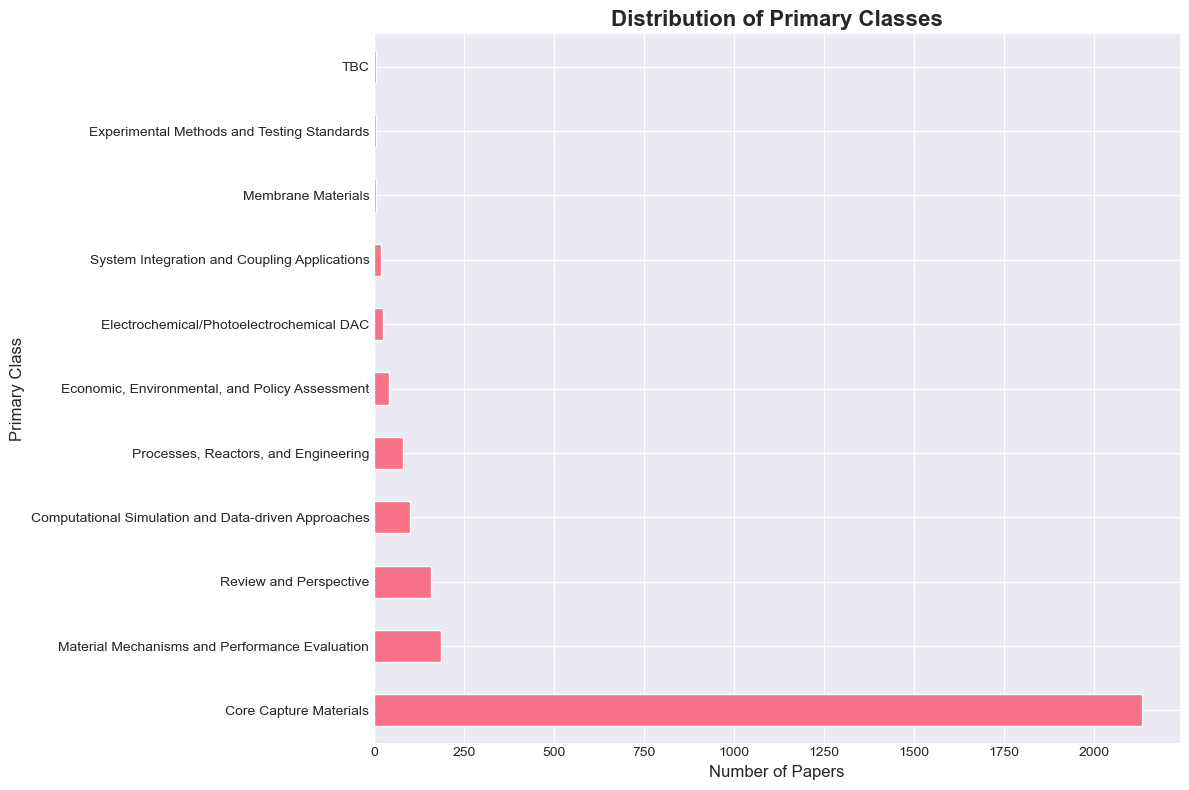

In [6]:
# Primary class distribution
class_distribution = df['Class'].value_counts()

print("Primary Class Distribution:")
print(class_distribution)

plot_horizontal_bar(class_distribution, 
                   'Distribution of Primary Classes',
                   'Number of Papers',
                   'Primary Class')

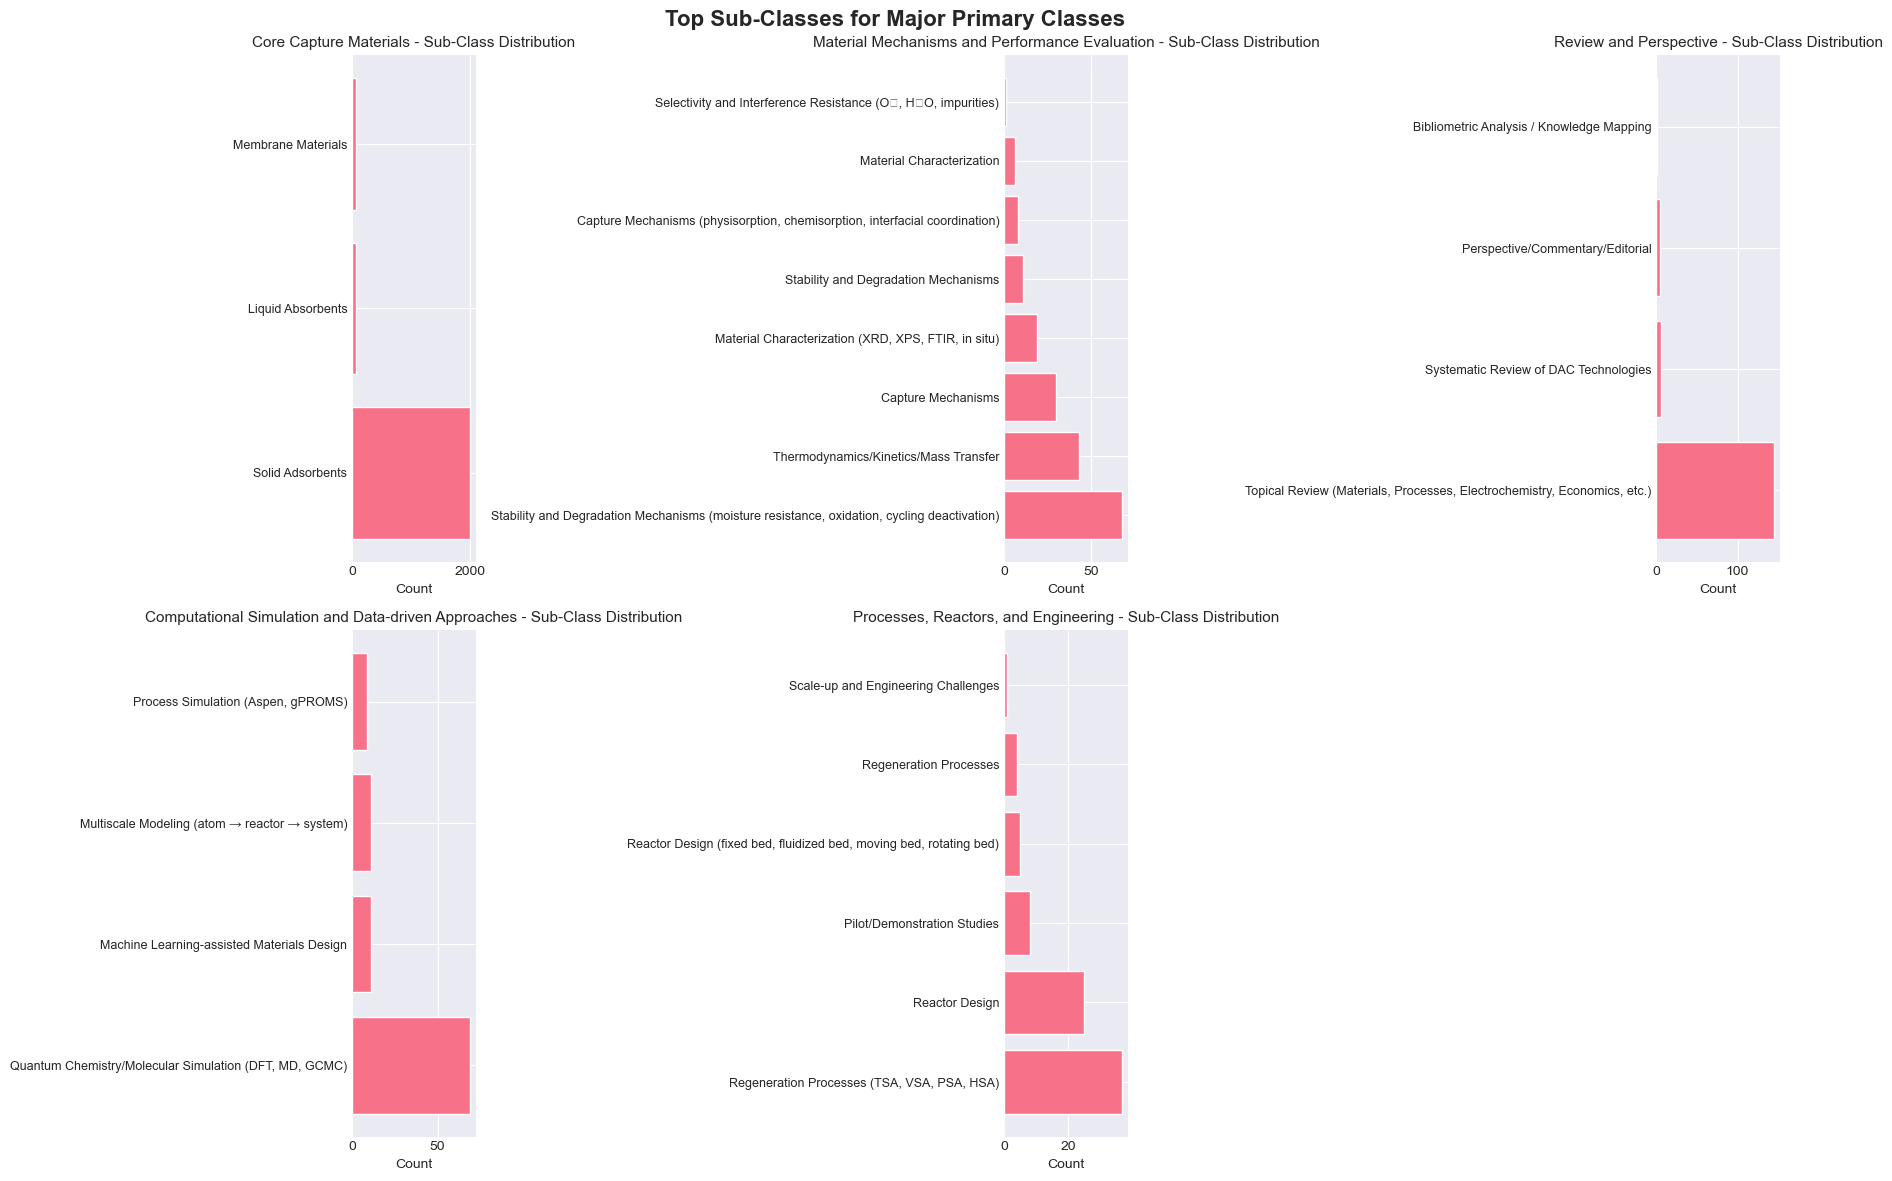

In [7]:
# Sub-Class 1 distribution for top classes
top_classes = class_distribution.index[:5]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, cls in enumerate(top_classes):
    if i < len(axes):
        subset = df[df['Class'] == cls]
        sub_class_dist = subset['Sub-Class 1'].value_counts().head(10)
        
        axes[i].barh(range(len(sub_class_dist)), sub_class_dist.values)
        axes[i].set_yticks(range(len(sub_class_dist)))
        axes[i].set_yticklabels(sub_class_dist.index, fontsize=9)
        axes[i].set_title(f'{cls} - Sub-Class Distribution', fontsize=11)
        axes[i].set_xlabel('Count')

# Hide empty subplots
for i in range(len(top_classes), len(axes)):
    axes[i].axis('off')

plt.suptitle('Top Sub-Classes for Major Primary Classes', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Interactive visualization of class hierarchy
import plotly.express as px

# Create a treemap for class hierarchy
hierarchy_data = df.groupby(['Class', 'Sub-Class 1']).size().reset_index(name='count')

fig = px.treemap(hierarchy_data, 
                 path=['Class', 'Sub-Class 1'], 
                 values='count',
                 title='Hierarchical Distribution of DAC Research Papers',
                 color='count',
                 color_continuous_scale='RdYlBu_r')

fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig.show()

## 3. Confidence Score Analysis

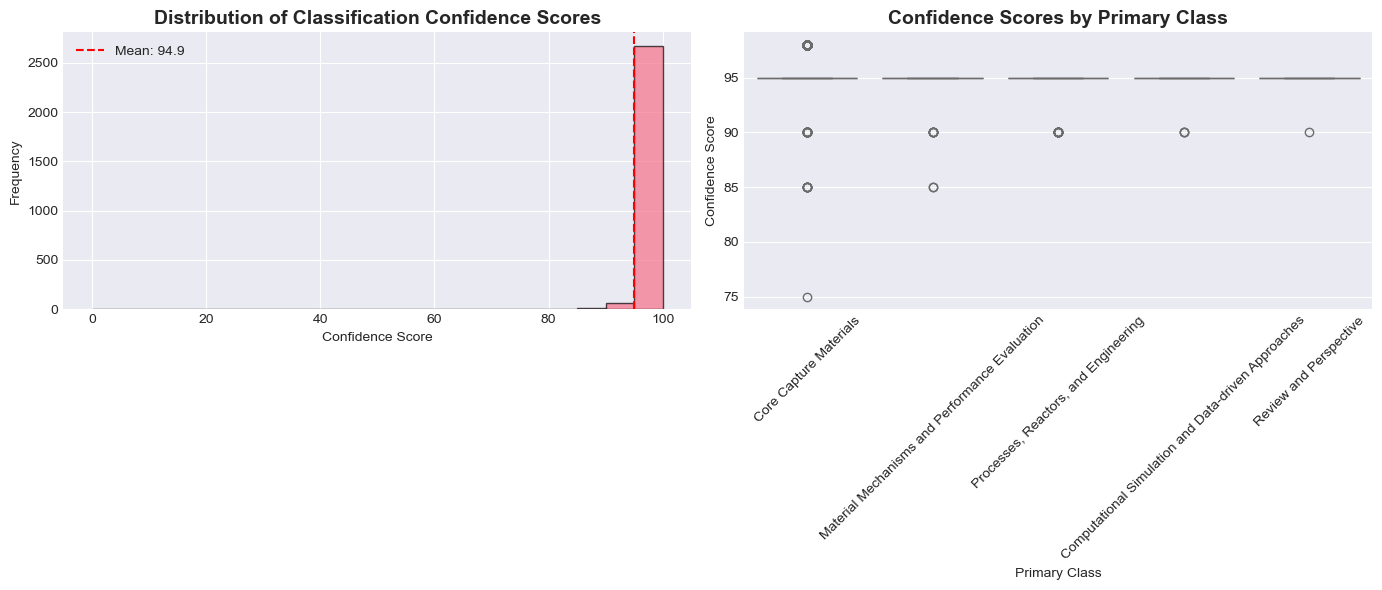

In [9]:
# Distribution of classification confidence
plt.figure(figsize=(14, 6))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(df['Classification_Confidence'], bins=20, edgecolor='black', alpha=0.7)
plt.title('Distribution of Classification Confidence Scores', fontsize=14, fontweight='bold')
plt.xlabel('Confidence Score')
plt.ylabel('Frequency')
plt.axvline(df['Classification_Confidence'].mean(), color='red', linestyle='--', 
            label=f'Mean: {df["Classification_Confidence"].mean():.1f}')
plt.legend()

# Box plot by primary class
plt.subplot(1, 2, 2)
top_classes_box = df[df['Class'].isin(top_classes)]
sns.boxplot(data=top_classes_box, x='Class', y='Classification_Confidence')
plt.title('Confidence Scores by Primary Class', fontsize=14, fontweight='bold')
plt.xlabel('Primary Class')
plt.ylabel('Confidence Score')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [10]:
# Confidence score statistics by class
confidence_stats = df.groupby('Class')['Classification_Confidence'].agg([
    'mean', 'median', 'std', 'min', 'max', 'count'
]).round(2).sort_values('mean', ascending=False)

print("Confidence Score Statistics by Primary Class:")
display(confidence_stats)

Confidence Score Statistics by Primary Class:


,mean,median,std,min,max,count
Class,,,,,,
Core Capture Materials,95.24,95.0,1.35,75,98,2132
Experimental Methods and Testing Standards,95.00,95.0,0.00,95,95,6
Review and Perspective,94.97,95.0,0.40,90,95,157
Computational Simulation and Data-driven Approaches,94.85,95.0,0.86,90,95,100
"Economic, Environmental, and Policy Assessment",94.75,95.0,1.10,90,95,40
Material Mechanisms and Performance Evaluation,94.70,95.0,1.39,85,95,186
Membrane Materials,94.17,95.0,2.04,90,95,6
"Processes, Reactors, and Engineering",94.00,95.0,2.01,90,95,80
Electrochemical/Photoelectrochemical DAC,92.50,95.0,11.23,40,95,24


In [11]:
# Generate summary statistics
print("SUMMARY STATISTICS FOR DAC CLASSIFICATION DATA")
print("=" * 50)

# Basic stats
print(f"\n1. Dataset Overview:")
print(f"   - Total papers: {len(df):,}")
print(f"   - Number of primary classes: {df['Class'].nunique()}")
print(f"   - Number of unique Sub-Class 1 categories: {df['Sub-Class 1'].nunique()}")
print(f"   - Average classification confidence: {df['Classification_Confidence'].mean():.1f}%")

# Top categories
print(f"\n2. Top Primary Classes:")
for i, (cls, count) in enumerate(class_distribution.head(5).items(), 1):
    percentage = (count / len(df)) * 100
    print(f"   {i}. {cls}: {count} papers ({percentage:.1f}%)")

# Confidence analysis
print(f"\n3. Confidence Analysis:")
print(f"   - Highest confidence class: {confidence_stats['mean'].idxmax()} ({confidence_stats['mean'].max():.1f}%)")
print(f"   - Lowest confidence class: {confidence_stats['mean'].idxmin()} ({confidence_stats['mean'].min():.1f}%)")
print(f"   - Papers with confidence ≥ 90%: {(df['Classification_Confidence'] >= 90).sum()} ({(df['Classification_Confidence'] >= 90).sum()/len(df)*100:.1f}%)")

# Missing data summary
print(f"\n5. Data Quality:")
for col in df.columns:
    missing = df[col].isnull().sum()
    if missing > 0:
        percentage = (missing / len(df)) * 100
        print(f"   - {col}: {missing} missing ({percentage:.1f}%)")

SUMMARY STATISTICS FOR DAC CLASSIFICATION DATA

1. Dataset Overview:
   - Total papers: 2,756
   - Number of primary classes: 11
   - Number of unique Sub-Class 1 categories: 42
   - Average classification confidence: 94.9%

2. Top Primary Classes:
   1. Core Capture Materials: 2132 papers (77.4%)
   2. Material Mechanisms and Performance Evaluation: 186 papers (6.7%)
   3. Review and Perspective: 157 papers (5.7%)
   4. Computational Simulation and Data-driven Approaches: 100 papers (3.6%)
   5. Processes, Reactors, and Engineering: 80 papers (2.9%)

3. Confidence Analysis:
   - Highest confidence class: Core Capture Materials (95.2%)
   - Lowest confidence class: TBC (20.0%)
   - Papers with confidence ≥ 90%: 2738 (99.3%)

5. Data Quality:
   - Sub-Class 1: 5 missing (0.2%)
   - Sub-Class 2: 583 missing (21.2%)
   - Sub-Class 3: 1319 missing (47.9%)
   - Secondary_Classification: 795 missing (28.8%)
   - Keywords: 1 missing (0.0%)
   - DOI: 1638 missing (59.4%)
